# NyayaRL — Train DefenceAgent (GRPO) on Google Colab

This notebook trains the **only trainable model** in NyayaRL — the PyTorch `DefenceAgent` policy — using Group Relative Policy Optimisation. The Judge and Prosecution agents are deterministic / rule-based, so this is the single "model training" notebook.

## Before you run
Upload **one** of the following to the Colab session (see `colab/README.md`):

1. A zip of the project root containing `nyayarl/`, `training/`, `rewards/`, `data/`, `config.yaml`, OR
2. The same folders unpacked at `/content/nyayarl-openenv/`.

Optional: mount Google Drive (Cell 2) so checkpoints survive runtime resets.

## What this notebook does
- Verifies GPU.
- (Optional) Mounts Drive for persistent checkpoints / logs.
- (Optional) Unpacks an uploaded `nyayarl_openenv.zip`.
- Installs PyTorch + PyYAML.
- Calls `training.run_training.main()` with a Colab-tuned config.
- Streams logs to `logs/training.jsonl` and writes checkpoints to `checkpoints/step_*.pt`.

## 1. Hardware check

In [1]:
import subprocess
try:
    print(subprocess.check_output(['nvidia-smi'], text=True))
except Exception:
    print('No NVIDIA GPU detected. Training will run on CPU (slower but works).')

import torch
print('torch:', torch.__version__, 'cuda available:', torch.cuda.is_available())

No NVIDIA GPU detected. Training will run on CPU (slower but works).
torch: 2.11.0 cuda available: False


## 2. (Optional) Mount Google Drive
Skip if you don't care about persistent checkpoints. If you mount, all artifacts will land under `/content/drive/MyDrive/nyayarl/`.

In [ ]:
USE_DRIVE = True  # set False to keep everything in the ephemeral Colab disk

DRIVE_ROOT = '/content/drive/MyDrive/nyayarl'
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    import os
    os.makedirs(DRIVE_ROOT, exist_ok=True)
    print('Drive root:', DRIVE_ROOT)

## 3. Get the project source into Colab
Pick **one** of the cells below.

- **3a** — upload a zip via the Colab Files panel (recommended for private repos / local edits).
- **3b** — clone from GitHub (if your repo is public).

In [ ]:
# 3a. Unpack uploaded zip ===================================================
# Steps:
#   1. In Colab's Files panel, upload `nyayarl_openenv.zip`.
#   2. Run this cell.
import os, zipfile, pathlib
ZIP_PATH = '/content/nyayarl_openenv.zip'
PROJECT_DIR = '/content/nyayarl-openenv'
if os.path.exists(ZIP_PATH):
    pathlib.Path(PROJECT_DIR).mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(PROJECT_DIR)
    # If the zip contained a top-level folder, flatten one level.
    entries = [p for p in pathlib.Path(PROJECT_DIR).iterdir() if not p.name.startswith('.')]
    if len(entries) == 1 and entries[0].is_dir() and not (entries[0] / 'nyayarl').exists() == False:
        # If the unpacked top folder already contains nyayarl/, keep it; else move children up.
        pass
    print('Unpacked to', PROJECT_DIR)
    print(os.listdir(PROJECT_DIR)[:20])
else:
    print('No zip found at', ZIP_PATH, '- skip this cell and use 3b instead.')

In [ ]:
# 3b. Clone from GitHub =====================================================
# Replace REPO_URL with your fork.
REPO_URL = 'https://github.com/ParthGurav29/NyayaRL.git'
PROJECT_DIR = '/content/nyayarl-openenv'
import os
if not os.path.exists(PROJECT_DIR):
    !git clone --depth 1 {REPO_URL} {PROJECT_DIR}
print(os.listdir(PROJECT_DIR)[:20])

## 4. Install Python dependencies
Colab already ships with PyTorch; we add `PyYAML` (training config). Skip `gradio`, `fastapi`, `anthropic` etc. — not needed for training.

In [2]:
!pip install -q pyyaml
# torch is preinstalled on Colab; verify versions
import torch, yaml
print('torch', torch.__version__, '| pyyaml', yaml.__version__)

torch 2.11.0 | pyyaml 6.0.3


## 5. Configure paths and training config
We override `checkpoint_dir` / `log_dir` to point at Drive (if mounted) so artifacts survive.

In [8]:
import os, sys, pathlib, yaml
PROJECT_DIR = '/Users/parthmangeshgurav/Desktop/nyayarl-openenv'
USE_DRIVE = False
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

USE_DRIVE = True  # keep in sync with cell 2
DRIVE_ROOT = '/content/drive/MyDrive/nyayarl'
if USE_DRIVE and os.path.isdir('/content/drive/MyDrive'):
    CKPT_DIR = os.path.join(DRIVE_ROOT, 'checkpoints')
    LOG_DIR  = os.path.join(DRIVE_ROOT, 'logs')
else:
    CKPT_DIR = os.path.join(PROJECT_DIR, 'checkpoints')
    LOG_DIR  = os.path.join(PROJECT_DIR, 'logs')
pathlib.Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)
pathlib.Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

# Tweak as needed. Defaults below mirror config.yaml but with a Colab-friendly
# step budget for a single GPU session.
config = {
    'total_train_steps': 2000,
    'eval_every': 250,
    'eval_episodes': 30,
    'checkpoint_every': 250,
    'checkpoint_dir': CKPT_DIR,
    'log_dir': LOG_DIR,
    'G': 16,
    'lr': 0.001,
    'clip_epsilon': 0.2,
    'entropy_coef': 0.05,
    'entropy_coef_final': 0.01,
    'entropy_anneal_steps': 10000,
    'window_size': 100,
    'promotion_threshold': 0.6,
}
CONFIG_PATH = os.path.join(PROJECT_DIR, 'config_colab.yaml')
with open(CONFIG_PATH, 'w') as f:
    yaml.safe_dump(config, f, sort_keys=False)
print('Wrote', CONFIG_PATH)
print('checkpoints ->', CKPT_DIR)
print('logs        ->', LOG_DIR)

Wrote /Users/parthmangeshgurav/Desktop/nyayarl-openenv/config_colab.yaml
checkpoints -> /Users/parthmangeshgurav/Desktop/nyayarl-openenv/checkpoints
logs        -> /Users/parthmangeshgurav/Desktop/nyayarl-openenv/logs


## 6. Run training
Calls `training.run_training.main` directly so we don't shell out — output streams into the notebook.

In [9]:
import importlib
import training.run_training as rt
importlib.reload(rt)
rt.main(CONFIG_PATH)

Loaded config from /Users/parthmangeshgurav/Desktop/nyayarl-openenv/config_colab.yaml
  total_train_steps: 2000
  G: 16, lr: 0.001

✅ Loaded checkpoint (strict) from step_004999.pt
Resumed from checkpoint: /Users/parthmangeshgurav/Desktop/nyayarl-openenv/checkpoints/step_004999.pt (step 4999)


Training complete. 2000 steps finished.
Final curriculum level: 4
Final alignment: 0.00%


## 7. Sanity check the saved checkpoint

In [10]:
import os, glob, json
ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, 'step_*.pt')))
print(f'{len(ckpts)} checkpoint(s) saved. Latest:', ckpts[-1] if ckpts else 'NONE')
if ckpts:
    import torch
    blob = torch.load(ckpts[-1], map_location='cpu', weights_only=False)
    print('checkpoint_format_version:', blob.get('checkpoint_format_version'))
    print('step:', blob.get('step'), 'curriculum_level:', blob.get('curriculum_level'))
    print('agent state keys:', len(blob.get('agent_state_dict', {})))

11 checkpoint(s) saved. Latest: /Users/parthmangeshgurav/Desktop/nyayarl-openenv/checkpoints/step_004999.pt
checkpoint_format_version: 2
step: 4999 curriculum_level: 4
agent state keys: 27


## 8. (Optional) Show last 20 training log lines

In [11]:
import os, json
log_path = os.path.join(LOG_DIR, 'training.jsonl')
if os.path.exists(log_path):
    with open(log_path) as f:
        lines = f.readlines()[-20:]
    for ln in lines:
        e = json.loads(ln)
        print(f"step={e['step']:>5} level={e['curriculum_level']} reward={e['mean_reward']:.2f} alignment={e['alignment']*100:.1f}% loss={e['policy_loss']:.4f}")
else:
    print('No log file at', log_path)

step= 1715 level=4 reward=14.63 alignment=100.0% loss=-0.1739
step= 1716 level=4 reward=13.44 alignment=99.0% loss=-0.1734
step= 1717 level=4 reward=14.59 alignment=99.0% loss=-0.1738
step= 1718 level=4 reward=13.29 alignment=99.0% loss=-0.1747
step= 1719 level=4 reward=13.26 alignment=99.0% loss=-0.1740
step= 1720 level=4 reward=12.01 alignment=99.0% loss=-0.1725
step= 1721 level=4 reward=14.50 alignment=99.0% loss=-0.1732
step= 1722 level=4 reward=14.79 alignment=99.0% loss=-0.1736
step= 1723 level=4 reward=13.54 alignment=100.0% loss=-0.1725
step= 1724 level=4 reward=10.69 alignment=100.0% loss=-0.1766
step= 1725 level=4 reward=10.99 alignment=100.0% loss=-0.1740
step= 1726 level=4 reward=14.77 alignment=100.0% loss=-0.1753
step= 1727 level=4 reward=13.44 alignment=100.0% loss=-0.1743
step= 1728 level=4 reward=7.27 alignment=100.0% loss=-0.1716
step= 1729 level=4 reward=10.88 alignment=100.0% loss=-0.1747
step= 1730 level=4 reward=10.98 alignment=100.0% loss=-0.1731
step= 1731 level

## 9. Training-progress graphs

Reads `logs/training.jsonl` produced by the run above and plots:

1. **Reward** (mean ± std band) vs step
2. **Alignment** (rolling) vs step, with eval-checkpoint scatter overlaid
3. **Policy loss & entropy** (twin axes) vs step
4. **Curriculum level** vs step (with promotion markers)

Plots are also saved as PNGs to `logs/plots/` so you can drop them into a report / slides.

Loaded 6735 log rows from /Users/parthmangeshgurav/Desktop/nyayarl-openenv/logs/training.jsonl


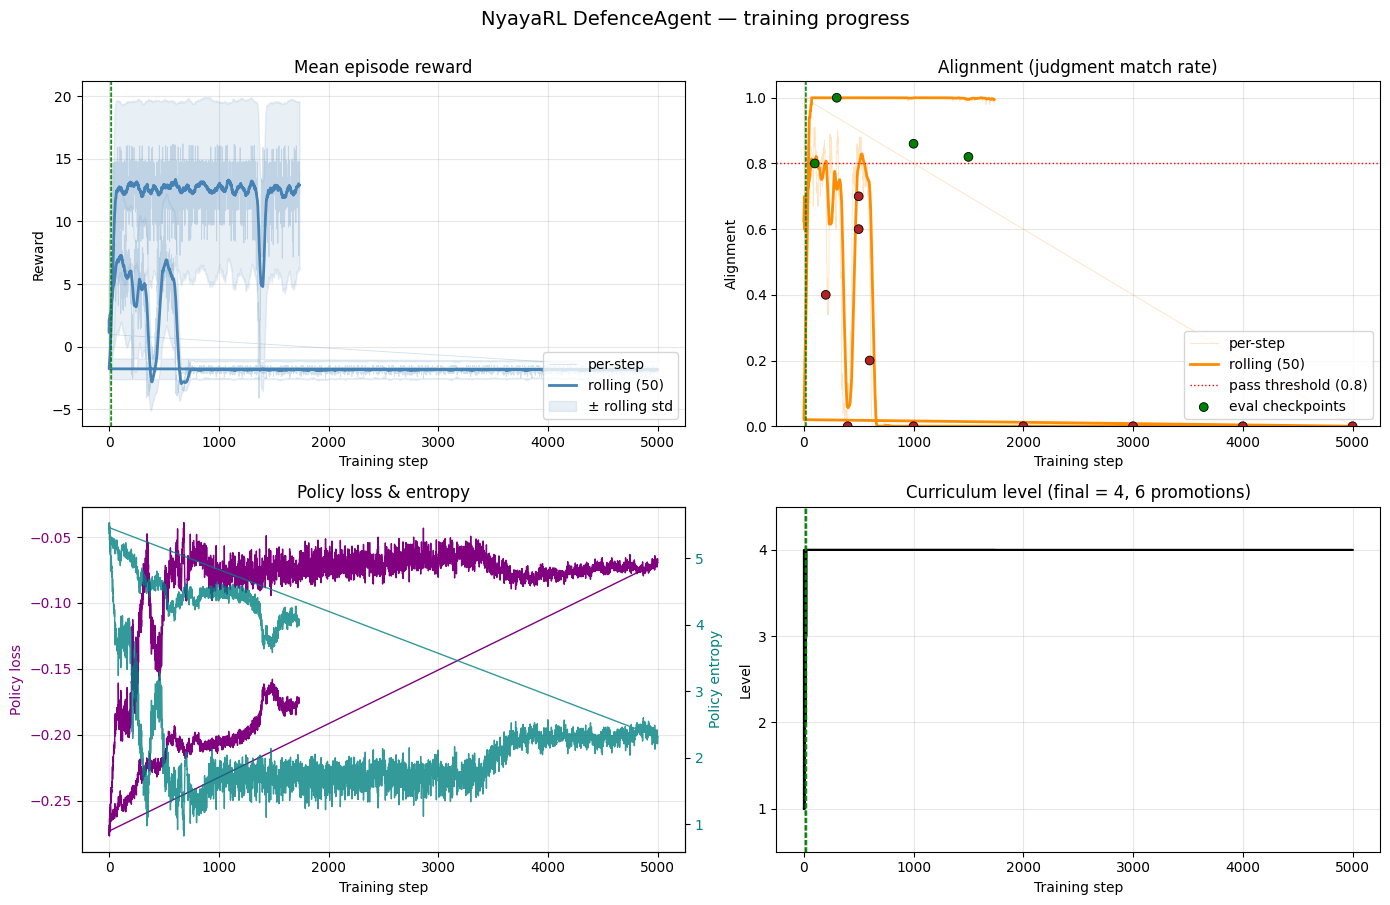

Saved combined figure -> /Users/parthmangeshgurav/Desktop/nyayarl-openenv/logs/plots/training_progress.png
Saved individual panels -> /Users/parthmangeshgurav/Desktop/nyayarl-openenv/logs/plots

Final-100-step summary:
  reward    mean = 12.528
  alignment mean = 0.996
  level (last)   = 4
  promotions     = 6  at steps [6, 13, 20, 6, 13, 20]
  last eval @ step 1499: alignment = 0.820, reward = 12.340, pass = True


In [12]:
import json, os, sys, subprocess
from pathlib import Path

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'matplotlib'])
    import matplotlib.pyplot as plt

if 'PROJECT_DIR' not in globals():
    PROJECT_DIR = '/Users/parthmangeshgurav/Desktop/nyayarl-openenv'
    print(f'(PROJECT_DIR not set — defaulting to {PROJECT_DIR})')

LOG_PATH = Path(PROJECT_DIR) / 'logs' / 'training.jsonl'
PLOTS_DIR = Path(PROJECT_DIR) / 'logs' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
assert LOG_PATH.exists(), f'Missing training log: {LOG_PATH} — run training first.'

rows = []
with open(LOG_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))
print(f'Loaded {len(rows)} log rows from {LOG_PATH}')

steps          = [r['step'] for r in rows]
mean_reward    = [r['mean_reward'] for r in rows]
std_reward     = [r['std_reward'] for r in rows]
alignment      = [r['alignment'] for r in rows]
policy_loss    = [r['policy_loss'] for r in rows]
entropy        = [r['entropy'] for r in rows]
levels         = [r['curriculum_level'] for r in rows]
promoted_steps = [r['step'] for r in rows if r.get('promoted')]
eval_steps     = [r['step'] for r in rows if r.get('eval')]
eval_align     = [r['eval']['mean_alignment'] for r in rows if r.get('eval')]
eval_pass      = [r['eval'].get('pass_threshold', False) for r in rows if r.get('eval')]


def _rolling(xs, k=50):
    from collections import deque
    out, buf = [], deque(maxlen=k)
    for x in xs:
        buf.append(x)
        out.append(sum(buf) / len(buf))
    return out


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('NyayaRL DefenceAgent — training progress', fontsize=14, y=1.00)

ax = axes[0, 0]
roll_r = _rolling(mean_reward, 50)
ax.plot(steps, mean_reward, color='steelblue', alpha=0.25, linewidth=0.6, label='per-step')
ax.plot(steps, roll_r,      color='steelblue', linewidth=2.0, label='rolling (50)')
lo = [m - s for m, s in zip(roll_r, _rolling(std_reward, 50))]
hi = [m + s for m, s in zip(roll_r, _rolling(std_reward, 50))]
ax.fill_between(steps, lo, hi, color='steelblue', alpha=0.12, label='± rolling std')
for ps in promoted_steps:
    ax.axvline(ps, color='green', linestyle='--', alpha=0.4, linewidth=0.8)
ax.set_title('Mean episode reward')
ax.set_xlabel('Training step'); ax.set_ylabel('Reward')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(steps, alignment,            color='darkorange', alpha=0.25, linewidth=0.6, label='per-step')
ax.plot(steps, _rolling(alignment, 50), color='darkorange', linewidth=2.0, label='rolling (50)')
ax.axhline(0.8, color='red', linestyle=':', linewidth=1.0, label='pass threshold (0.8)')
if eval_steps:
    colours = ['green' if p else 'firebrick' for p in eval_pass]
    ax.scatter(eval_steps, eval_align, c=colours, s=40, edgecolors='black',
               linewidths=0.6, zorder=5, label='eval checkpoints')
for ps in promoted_steps:
    ax.axvline(ps, color='green', linestyle='--', alpha=0.4, linewidth=0.8)
ax.set_ylim(0, 1.05)
ax.set_title('Alignment (judgment match rate)')
ax.set_xlabel('Training step'); ax.set_ylabel('Alignment')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(steps, policy_loss, color='purple', linewidth=1.0, label='policy loss')
ax.set_xlabel('Training step'); ax.set_ylabel('Policy loss', color='purple')
ax.tick_params(axis='y', labelcolor='purple')
ax2 = ax.twinx()
ax2.plot(steps, entropy, color='teal', linewidth=1.0, alpha=0.8, label='entropy')
ax2.set_ylabel('Policy entropy', color='teal')
ax2.tick_params(axis='y', labelcolor='teal')
ax.set_title('Policy loss & entropy'); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.step(steps, levels, where='post', color='black', linewidth=1.5)
for ps in promoted_steps:
    ax.axvline(ps, color='green', linestyle='--', alpha=0.6, linewidth=1.0)
ax.set_yticks([1, 2, 3, 4])
ax.set_ylim(0.5, 4.5)
ax.set_title(f'Curriculum level (final = {levels[-1]}, {len(promoted_steps)} promotions)')
ax.set_xlabel('Training step'); ax.set_ylabel('Level')
ax.grid(alpha=0.3)

plt.tight_layout()
combined_path = PLOTS_DIR / 'training_progress.png'
fig.savefig(combined_path, dpi=140, bbox_inches='tight')
plt.show()
print('Saved combined figure ->', combined_path)

panel_map = {
    'reward':       axes[0, 0],
    'alignment':    axes[0, 1],
    'loss_entropy': axes[1, 0],
    'curriculum':   axes[1, 1],
}
renderer = fig.canvas.get_renderer()
for label, sub in panel_map.items():
    extent = sub.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.10)
    fig.savefig(PLOTS_DIR / f'{label}.png', dpi=140, bbox_inches=extent)
print('Saved individual panels ->', PLOTS_DIR)

print('\nFinal-100-step summary:')
tail = rows[-100:]
print(f'  reward    mean = {sum(r["mean_reward"] for r in tail)/len(tail):.3f}')
print(f'  alignment mean = {sum(r["alignment"]   for r in tail)/len(tail):.3f}')
print(f'  level (last)   = {tail[-1]["curriculum_level"]}')
print(f'  promotions     = {len(promoted_steps)}  at steps {promoted_steps[:10]}{"..." if len(promoted_steps) > 10 else ""}')
if eval_steps:
    last_eval = next(r for r in reversed(rows) if r.get('eval'))
    print(f"  last eval @ step {last_eval['step']}: alignment = {last_eval['eval']['mean_alignment']:.3f}, "
          f"reward = {last_eval['eval']['mean_reward']:.3f}, pass = {last_eval['eval'].get('pass_threshold')}")